In [ ]:
#Algorithm outline and testing
""" GOAL: KALMAN, ASSOCIATION, TRACK LIFECYCLE"""

In [33]:
# === PART 1: DETECT & LOCALIZE FLIES PER FRAME ===
""" goal is to record latency of frame substraction, ensure that program can keep track of multiple flies in each frame """

#imports
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from collections import deque

In [35]:
#constants
VIDEO_PATH = "LUCID_TRI032S-M_251700592__20251114112116359_video3.avi" #path to AVI file
DOWNSCALE = 1.0 #<1.0 to downscale frames for speed
THRESH_VAL = 25 # frame subtraction threshold
MIN_AREA = 5 # minimum blob area (pixels)
MAX_AREA = 500 # max blob area (pixels)
MAX_MISSED = 10 # allows tracks to survive 10 frames without a detection
MAX_TRACK_DIST = 50 # max distance for track association (pixels)
HISTORY = 50 # frame to keep for plotting

# ROI Configuration
# define ROI as fractions of frame dimensions
ROI_X_MIN = 0.5
ROI_Y_MIN = 0.0

# static object detection
BACKGROUND_ALPHA = 0.005 # running background update rate
PERSIST_THRESH = 15 # how dark is "fly-like"
PERSIST_FRAMES = 20 #how long it must persist

# Precomputed morphology kernels (create once)
kernel3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
kernel5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

# Precompute a small circle mask for radius 6
CIRCLE_RADIUS = 20
circle_mask = np.zeros((2*CIRCLE_RADIUS+1, 2*CIRCLE_RADIUS+1), dtype=np.uint8)
cv2.circle(circle_mask, (CIRCLE_RADIUS, CIRCLE_RADIUS), CIRCLE_RADIUS, 255, -1)


# manual kalman transition model
DT = 1.0 # assume constant frame interval

#transition
F = np.array([
    [1, 0, DT, 0],
    [0, 1, 0, DT],
    [0, 0, 1,  0],
    [0, 0, 0,  1]
], dtype=np.float32)

# measurement/observation
H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
], dtype=np.float32)

# noise 
Q = np.eye(4, dtype=np.float32) * 0.01 # process noise
R = np.eye(2, dtype=np.float32) * 4.0 # measurement noise

# Kalman state vocabulary 
# init --> just spawned, not trusted
# tracked --> stable, being updated
# stationary --> velocity near zero for N frames
# lost --> missed but not yet deleted (minimize # of these to avoid egregious computation time)
INIT_FRAMES=3
STATIONARY_VEL_THRESH = 0.3
STATIONARY_FRAMES = 10

In [37]:
#tracking class
class Track: 
    def __init__(self, track_id, centroid): 
        self.id = track_id
        self.centroids = deque(maxlen=HISTORY)
        self.centroids.append(centroid)
        #self.last_seen = 0 # frame idx when last seen
        self.missed = 0 # num of consecutive frames w/o detection
        self.age=1
        self.hits=1 #successful updates

    # add kalman state
        x, y = centroid
        # initialize new flies to have unknown velocity in kalman
        #self.x = np.array([[d[0]], [d[1]], [0.], [0.]])
        self.x = np.array([[x], [y], [0.0], [0.0]]) #state
        self.P = np.eye(4) * 100.0 # covariance

        self.state_label = "init" # initial state initialized 

        # store history for post-hoc metrics & visualization 
        self.history = {
            "meas": [], #detection assigned
            "pred": [], #prediction before update
            "post": [], #state after update
            "vel": [], #velocity magnitude
        }
        self.stationary_count=0

    @property
    def last_position(self): 
        return self.centroids[-1] # returns last position stored in centroid

In [39]:
# utility functions
def preprocess_and_crop(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    #gray =cv2.equalizeHist(gray)

    h, w = gray.shape 

    # Define ROI fractions (example: right half)
    x0 = int(ROI_X_MIN * w)
    y0 = int(ROI_Y_MIN * h)
    x1 = w
    y1 = h

    roi = gray[y0:y1, x0:x1]

    # force consistent minimum size
    if roi.shape[0] < 8 or roi.shape[1] < 8:
        raise ValueError(f"ROI too small: {roi.shape} from frame {gray.shape}")
    return roi, (x0, y0)

def detect_moving_objects_fast(prev_gray, curr_gray):
    diff = cv2.absdiff(curr_gray, prev_gray)
    diff = cv2.GaussianBlur(diff, (5,5), 0)
    _, thresh = cv2.threshold(diff, THRESH_VAL, 255, cv2.THRESH_BINARY)
    # reuse kernel3, do NOT create a new one
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel3)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh)
    detections = []
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if MIN_AREA <= area <= MAX_AREA:
            cx, cy = centroids[i]
            detections.append((int(cx), int(cy)))
    return detections, thresh

def track_position_for_matching(t):
    return (int(t.x[0,0]), int(t.x[1,0]))  # predicted (x,y)


def associate_detections_to_tracking_fast(detections, tracks, next_id):
    if not detections: 
        for t in tracks: 
            t.missed +=1 
        return [t for t in tracks if t.missed <= MAX_MISSED], next_id

    used = np.zeros(len(detections), dtype=bool)

    # match existing tracks using greedy algorithm 
    for t in tracks: 
        dists = np.linalg.norm(np.array(detections) - np.array(track_position_for_matching(t)), axis = 1)
        idx = np.argmin(dists)

        if dists[idx] < MAX_TRACK_DIST and not used[idx]: 
            z = detections[idx]
            kalman_update(t, z) 
            t.centroids.append(z)
            t.missed=0
            t.hits += 1
            update_track_state(t)
            used[idx] = True
        else: 
            t.missed += 1
            if t.missed > 0: 
                t.state_label = "lost"

    # generate new tracks ONLY for unmatched detections
    for i, d in enumerate (detections): 
        if not used[i]: 
            tracks.append(Track(next_id, d))
            next_id += 1

    # remove old tracks
    tracks = [t for t in tracks if t.missed <=MAX_MISSED]

    return tracks, next_id


def merge_detections(move_dets, static_dets, tracks, move_radius = 15, static_radius = 6):
    merged = list(move_dets)

    track_positions = np.array([t.last_position for t in tracks]) if tracks else np.empty((0,2))

    # static is confirmation, not discovery
    for sd in static_dets:
        if len(track_positions) == 0: 
            continue
        dists = np.linalg.norm(track_positions - np.array(sd), axis =1)

        # static deteections only confirm 
        if np.min(dists) < static_radius: 
            merged.append(sd)

    return merged

def deduplicate_tracks(tracks, radius=5): 
    # prevent same location collapse
    if len(tracks) <=1: 
        return tracks

    keep = []
    for t in tracks: 
        if not any(np.linalg.norm(
            np.array(t.last_position) - np.array(k.last_position)
        ) < radius for k in keep): 
            keep.append(t)
    return keep



In [ ]:
# KALMAN FILTERING FUNCTIONS
# kalman predictions
def kalman_predict(track): 
    # F = state transition
    # Q = noise matrix
    track.history["pred"].append(track.x[:2].flatten()) # store predicted (x,y)
    track.x = F @ track.x
    track.P = F @ track.P @ F.T + Q

# update kalman if detection is assigned 
def kalman_update(track, z): 
    # H = measurement
    # R = noise matrix
    z = np.array(z).reshape(2,1)
    track.history["meas"].append(z.flatten()) # store detection
    
    y = z - H @ track.x
    S = H @ track.P @H.T + R
    K = track.P @ H.T @ np.linalg.inv(S)

    track.x = track.x + K @ y
    track.P = (np.eye(4) - K @ H) @ track.P

    track.history["post"].append(track.x[:2].flatten()) #store updated (x,y)
    track.history["vel"].append(np.linalg.norm(track.x[2:4])) #vx, vy magnitude

def update_track_state(t): 
    vx, vy = t.x[2,0], t.x[3,0]
    speed = np.hypot(vx, vy)

    if t.hits < INIT_FRAMES: #init state
        t.state_label = "init"
    elif speed < STATIONARY_VEL_THRESH: # stationary state
        t.stationary_count += 1
        if t.stationary_count >= STATIONARY_FRAMES: 
            t.state_label = "stationary"
        else:
            t.state_label = "tracked" # tracked states
    else: 
        t.stationary_count = 0
        t.state_label = "tracked" # TODO or tracked? 
        
def kalman_lookahead(track, N, F=F): 
    """Predict position N frames ahead without modifying track."""
    x = track.x.copy()
    for _ in range(N): 
        x = F @ x
    return x[:2].flatten()

In [ ]:
# SCORING FUNCTION
def score_targets(tracks, laser_pos=(0,0), weight_distance=1.0, weight_sep=0.5):
    """
    Assign a score to each track. Higher score = better target for laser.
    tracks: list of Track objects
    laser_pos: current laser coordinates (x, y)
    Returns: list of (track, score)
    """
    scores = []
    predicted_positions = [t.x[:2].flatten() for t in tracks]

    for i, t in enumerate(tracks):
        px, py = predicted_positions[i]
        # 1. Distance from laser
        dist = np.linalg.norm(np.array([px, py]) - np.array(laser_pos))
        score = -weight_distance * dist  # closer = higher score

        # 2. Penalize targets close to others (avoid collisions)
        if len(predicted_positions) > 1:
            sep_penalty = 0
            for j, other in enumerate(predicted_positions):
                if i != j:
                    sep = np.linalg.norm(predicted_positions[i] - other)
                    sep_penalty += np.exp(-sep/20)  # sharp penalty for very close targets
            score -= weight_sep * sep_penalty

        scores.append((t, score))

    # Sort by score descending
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores


In [41]:
# MAIN PROCESSING LOOP

def process_video(): 
    print(f"beginning...\n") 
    capture = cv2.VideoCapture(VIDEO_PATH)
    assert capture.isOpened(), "Could not open video file"
    
    ret, frame = capture.read()
    if not ret: 
        raise RuntimeError("Failed to read first frame")
        
    prev_gray, roi_offset = preprocess_and_crop(frame)
    
    #initialize background model for static detection
    bg_model_fast = prev_gray.copy() 
    bg_model_slow = prev_gray.copy() #np.ones_like(prev_gray, dtype=np.uint8) * 255
    persist_map=np.zeros_like(prev_gray, dtype=np.uint8)
    
    # instantiate empty arrays for tracking and latency calculations
    tracks = [] #store tracking in array
    next_track_id = 0 
    #explicit multi-target capacity metrics
    latencies, det_counts, track_counts, frames, thresh_frames = [], [], [], [], []
       
        #frames = []
        #thresh_frames = []
    
    # precompute grids ONCE
    H, W = prev_gray.shape
    yy, xx = np.mgrid[0:H, 0:W]
    CIRCLE_RADIUS_SQ = CIRCLE_RADIUS ** 2
    
    frame_idx = 0
    
    #begin loop, occurs over duration of video
    while True: 
        ret, frame = capture.read()
        if not ret: 
            break
    
        start_frame = time.perf_counter() #records detection speed
    
         # Preprocess & crop
        start = time.perf_counter()
        curr_gray, _ = preprocess_and_crop(frame)
        t_preprocess = time.perf_counter() - start
    
        # Moving detection
        start = time.perf_counter()
        move_dets, thresh = detect_moving_objects_fast(prev_gray, curr_gray)
        t_move = time.perf_counter() - start
    
        # Static detection
        start = time.perf_counter()
        static_dets = detect_static_objects_fast(
            curr_gray, bg_model_fast, bg_model_slow, persist_map
        ) #previously used tracks
        t_static = time.perf_counter() - start

        # kalman predictions
        start = time.perf_counter()
        for t in tracks: 
            kalman_predict(t)
        t_kalman = time.perf_counter() - start
    
        # Merge detections + tracking
        start = time.perf_counter()
        detections = merge_detections(move_dets, static_dets, tracks)
        tracks, next_track_id = associate_detections_to_tracking_fast(
            detections, tracks, next_track_id
        )
        tracks = deduplicate_tracks(tracks) # one track per fly, protect stationary leak
        t_tracking = time.perf_counter() - start

        # scoring/target selection
        laser_position = (0, 0)  # example: top-left corner
        scored_tracks = score_targets(tracks, laser_pos=laser_position)
        
        # Pick top N targets
        TOP_N = 1  # choose one target to engage
        top_targets = [t for t, s in scored_tracks[:TOP_N]]
        
        for t in top_targets:
            px, py = t.x[0,0], t.x[1,0]
            cv2.circle(visual, (px, py), 8, (0,0,255), 2) # big red circle for selected target
            print(f"Targeting Track ID {t.id} at predicted position ({px:.1f}, {py:.1f})")
            
    
        # Background update
        start_bg = time.perf_counter()

        # update slow background -- never mask 
        bg_model_slow = cv2.addWeighted(
                bg_model_slow, 1 - SLOW_ALPHA, 
                curr_gray, SLOW_ALPHA, 0)

        # update fast background (mask flies) 
        if len(tracks) == 0:
            # no flies --> full fast update
            bg_model_fast = cv2.addWeighted(
                bg_model_fast, 1 - BACKGROUND_ALPHA,
                curr_gray, BACKGROUND_ALPHA, 0
            )
            
        else:
            fly_mask = np.zeros_like(curr_gray, dtype=np.uint8)
        
            for t in tracks:
                x, y = t.last_position
        
                x0 = max(0, x - CIRCLE_RADIUS)
                y0 = max(0, y - CIRCLE_RADIUS)
                x1 = min(W, x + CIRCLE_RADIUS + 1)
                y1 = min(H, y + CIRCLE_RADIUS + 1)
        
                cm_x0 = x0 - (x - CIRCLE_RADIUS)
                cm_y0 = y0 - (y - CIRCLE_RADIUS)
                cm_x1 = cm_x0 + (x1 - x0)
                cm_y1 = cm_y0 + (y1 - y0)
        
                fly_mask[y0:y1, x0:x1] |= circle_mask[cm_y0:cm_y1, cm_x0:cm_x1]

            # compute blended background ONCE
            blended_fast = cv2.addWeighted(
                bg_model_fast, 1 - BACKGROUND_ALPHA,
                curr_gray, BACKGROUND_ALPHA, 0
            )
            #bg_model[fly_mask == 0] = cv2.addWeighted(
             #   bg_model[fly_mask == 0], 1 - BACKGROUND_ALPHA,
              #  curr_gray[fly_mask == 0], BACKGROUND_ALPHA, 0
            #)
            #update only non-fly pixels TODO is this fast or slow
            bg_model_fast[fly_mask == 0] = blended_fast[fly_mask == 0]
            
        
        t_bg = (time.perf_counter() - start_bg)
        
        # Visualization
        start = time.perf_counter()
        visual = cv2.cvtColor(curr_gray, cv2.COLOR_GRAY2BGR)
        cv2.rectangle(visual, (0,0), (visual.shape[1]-1, visual.shape[0]-1), (255,255,0), 1)
        for t in tracks:
            # draw centroid history 
            for i in range(1, len(t.centroids)): 
                cv2.line(visual, t.centroids[i-1], t.centroids[i], (0,255,0), 1)

            # draw Kalman post-state prediction (blue circles)
            pred_x, pred_y = t.history["post"][-1] if t.history["post"] else t.last_position
            cv2.circle(visual, (int(pred_x), int(pred_y)), 3, (255,0,0), -1) 

            # original detection circle
            cv2.circle(visual, t.last_position, 3, (0,0,255), -1)  # red = detection
            cv2.putText(visual, f"ID {t.id}", (t.last_position[0]+5, t.last_position[1]-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,0,0), 1)

            #draw predicted vs measured as lines
            if t.history["meas"] and t.history["post"]: 
                meas_x, meas_y = t.history["meas"][-1]
                post_x, post_y = t.history["post"][-1] 
                cv2.line(visual, (int(meas_x), int(meas_y)), (int(post_x), int(post_y)), (0, 255, 255), 1)


            
            # measured 
            mx, my = t.last_position
            cv2.circle(visual, (mx, my), 3, (0,0,255), -1)

            # predicted 
            px, py = int(t.x[0,0]), int(t.x[1,0])
            cv2.circle(visual, (px,py), 5, (255, 0, 0), 1)

            # velocity arrow
            vx, vy = t.x[2,0], t.x[3,0]
            end = (int(px + 8*vx), int(py + 8*vy))
            cv2.arrowedLine(visual, (px, py), end, (0, 255, 255), 1, tipLength=0.3)
            
            # label
            # do NOT repeat n times (moved outside loop)
            #cv2.circle(visual, t.last_position, 3, (0,0,255), -1)
            label = f"ID {t.id} | {t.state_label}"
            cv2.putText(
                visual, label, 
                (px+6, py-6), 
                cv2.FONT_HERSHEY_SIMPLEX, 
                0.4, (255,255,255), 1
            )
            if frame_idx % 10 == 0:
                frames.append(visual.copy())
                thresh_frames.append(thresh.copy())
        t_vis = time.perf_counter() - start
    
        # Metrics
        total_frame = (time.perf_counter() - start_frame) * 1000.0
        total_frame_no_vis = (t_preprocess + t_move + t_static + t_kalman + t_tracking + t_bg) * 1000.0

        latencies.append(total_frame_no_vis)
        det_counts.append(len(detections))
        track_counts.append(len(tracks))

    
        prev_gray = curr_gray
        frame_idx += 1
    

    capture.release()
    print ("Done processing.")
    return latencies, det_counts, track_counts, frames, thresh_frames, tracks
        

In [43]:
import cProfile
import pstats

#cProfile.run('process_video()', 'profile_results')
#p = pstats.Stats('profile_results')
#p.strip_dirs().sort_stats('cumtime').print_stats(50)

latencies, det_counts, track_counts, frames, thresh_frames, tracks = process_video()

beginning...

Frame 0: preprocess=3.4ms, move=16.4ms, static=30.6ms, kalman=0.0ms tracking=0.1ms, bg=4.5ms, vis=1.7ms, total=56.7ms
Frame 1: preprocess=2.5ms, move=12.5ms, static=30.6ms, kalman=0.0ms tracking=0.3ms, bg=12.4ms, vis=2.1ms, total=60.4ms
Frame 2: preprocess=1.6ms, move=12.7ms, static=29.2ms, kalman=0.2ms tracking=1.4ms, bg=12.4ms, vis=2.9ms, total=60.3ms
Frame 3: preprocess=2.2ms, move=13.2ms, static=30.4ms, kalman=0.3ms tracking=1.4ms, bg=13.0ms, vis=3.1ms, total=63.5ms
Frame 4: preprocess=1.8ms, move=13.8ms, static=30.6ms, kalman=0.3ms tracking=1.3ms, bg=13.9ms, vis=2.5ms, total=64.3ms
Frame 5: preprocess=1.5ms, move=12.3ms, static=29.7ms, kalman=0.3ms tracking=1.4ms, bg=13.5ms, vis=2.7ms, total=61.4ms
Frame 6: preprocess=2.4ms, move=12.1ms, static=29.4ms, kalman=0.2ms tracking=1.3ms, bg=13.7ms, vis=2.1ms, total=61.3ms
Frame 7: preprocess=2.4ms, move=12.5ms, static=29.9ms, kalman=0.3ms tracking=1.1ms, bg=11.6ms, vis=2.3ms, total=60.2ms
Frame 8: preprocess=2.0ms, move=12.

Average per-frame latency: 90.50 ms
Max per-frame latency: 2126.98 ms
Estimated FPS capability: 11.0 FPS


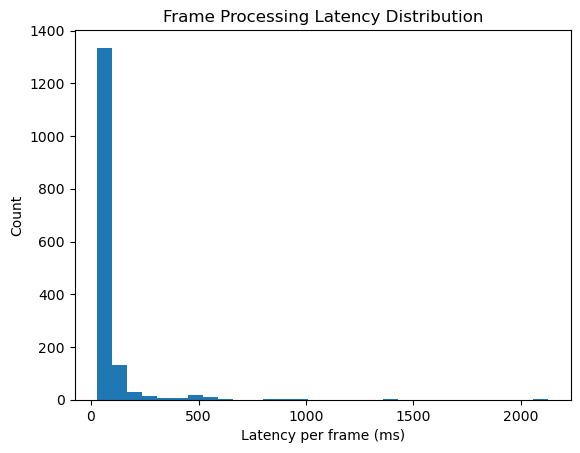

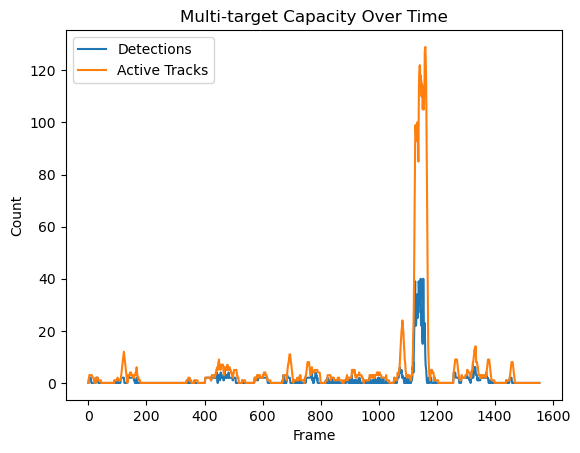

In [45]:
# === RESULTS AND DIAGNOSTICS ===

# latency metrics
#print(f"Processed {frame_idx} frames")
print(f"Average per-frame latency: {np.mean(latencies):.2f} ms")
print(f"Max per-frame latency: {np.max(latencies):.2f} ms")
print(f"Estimated FPS capability: {1000.0 / np.mean(latencies):.1f} FPS")

# plot latency distribution 
plt.figure()
plt.hist(latencies, bins=30)
plt.xlabel("Latency per frame (ms)")
plt.ylabel("Count")
plt.title("Frame Processing Latency Distribution")
plt.show()

#plot detection metrics to quantitatively show scaling behavior
plt.figure()
plt.plot(det_counts, label="Detections")
plt.plot(track_counts, label="Active Tracks")
plt.legend()
plt.title("Multi-target Capacity Over Time")
plt.xlabel("Frame")
plt.ylabel("Count")
plt.show()

In [ ]:
# === SET UP ABLATION EXPERIMENTS === 

In [ ]:
# == EXPERIMENT ONE: LOOKAHEAD NUM. OF FRAMES ===

# Compute prediction error vs lookahead
LOOKAHEADS = [1, 3, 5, 10, 20]
errors = {N: [] for N in LOOKAHEADS}

for t in tracks: 
    meas = np.array(t.history["meas"])
    if len(meas) < max(LOOKAHEADS) +1:
        continue

    for N in LOOKAHEADS: 
        for i in range(len(meas) - N): 
            pred = kalman_lookahead(t, N)
            err = np.linalg.norm(meas[i+N]-pred)
            errors[N].append(err)
            

In [ ]:
# plot lookahead error
# TODO SEE IF I CAN GET BREAKDOWN OF THAT "STATE" IE IF ITS STATIONARY, MOVING, DIFFERENT VELOCITY GROUPS ETC
plt.figure()
for N, e in errors.items(): 
    plt.plot(np.sort(e), label=f"N={N}")
plt.legend()
plt.xlabel("Sample idx")
plt.ylabel("Prediction error (pixels)")
plt.title("Kalman lookeahead error vs horizon")
plt.show 

In [ ]:
# === EXPERIMENT 2: STATIONARY VS MOVING VELOCITY VERIFICATION

In [ ]:

# to determine: is kalman velocity estimate reliable enough to classify stationary flies?

vel_stationary = []
vel_tracked = []

for t in tracks: 
    if t.state_label == "stationary": 
        vel_stationary.extend(t.history["vel"])
    elif t.state_label == "tracked": 
        vel_tracked.extend(t.history["vel"])

In [ ]:
# plot velocity histograms - determines if STATIONARY_VEL_THRESH is justified

plt.figure()
plt.hist(vel_stationary, bins=30, alpha=0.6, label="Stationary")
plt.hist(vel_tracked, bins=30, alpha=0.6, label="Tracked")
plt.axvline(STATIONARY_VEL_THRESH, color='r', linestyle='--')
plt.legend()
plt.xlabel("Velocity magnitude (pixels/frame)")
plt.ylabel("Count")
plt.title("Kalman Velocity Separation")
plt.show()


In [ ]:
# EXPERIMENT 3: SCORING FUNCTION ABLATION (TARGET SELECTION)

In [ ]:
# base scoring function 

def score_target(track, w_dist=1.0, w_vel=1.0, w_iso=1.0):
    pos = track.x[:2].flatten()
    vel = np.linalg.norm(track.x[2:4])
    
    # distance to center (or laser origin)
    dist = np.linalg.norm(pos - LASER_ORIGIN)

    # isolation penalty
    dists = [
        np.linalg.norm(pos - t.x[:2].flatten())
        for t in tracks if t.id != track.id
    ]
    isolation = min(dists) if dists else 50

    return (
        -w_dist * dist +
        -w_vel * vel +
        +w_iso * isolation
    )

In [ ]:
# ablation grid
# todo verify if i need to make these matrices in numpy arrays instead

WEIGHTS = [
    (1,0,0),
    (1,1,0),
    (1,1,1),
    (0.5,1,1),
]

results = {}

for w in WEIGHTS:
    scores = []
    for t in tracks:
        scores.append(score_target(t, *w))
    results[w] = np.mean(scores)


In [ ]:
# compare weight effects
# shows which scoring terms actually matter, which weights can be dropped for speed
for w, s in results.items():
    print(f"Weights {w} → avg score {s:.2f}")


In [ ]:
# ===EXPERIMENT 4: MULTI-TARGET LOAD VS TRACKING COST ===

# when does tracking explode computationally -- 
# TODO improve tracking performance & then re-run as well 

In [ ]:
# tracking costs vs targets 
plt.figure()
plt.scatter(track_counts, latencies, alpha=0.5)
plt.xlabel("Active tracks")
plt.ylabel("Latency (ms, no visualization)")
plt.title("Latency vs Active Tracks")
plt.show()

In [ ]:
# === EXPERIMENT 5: STATIC DETECTION SENSITIVITY ===


In [ ]:
# persistence param sweep 
PERSIST_VALUES = [10, 15, 20, 30]
static_counts = {}

for p in PERSIST_VALUES:
    static_counts[p] = sum(
        1 for t in tracks if t.state_label == "stationary"
    )


In [ ]:
# plot
plt.figure()
plt.plot(list(static_counts.keys()), list(static_counts.values()), marker='o')
plt.xlabel("PERSIST_FRAMES")
plt.ylabel("Detected stationary tracks")
plt.title("Static Detection Sensitivity")
plt.show()
